<a href="https://colab.research.google.com/github/tarasovEgor/DeepLearningKurs/blob/main/src/lab_4/VAE_lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторная работа 4.**

---

## Генерация данных с использованием вариационных автоэнкодеров (VAE).

---

## **Цель работы:** изучить принципы работы вариационных автокодировщиков (VAE) и их применение для генерации новых данных. Также будет проведен анализ латентного пространства и исследованы возможности его интерпретации.


### 0. Init steps

---

#### Импорты библиотек и настройка среды:

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Lambda, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Подготовка данных

#### 1.1 Загрузка и нормализация MNIST:

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация пикселей из диапазона [0, 255] в диапазон [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Добавляем размерность канала: было (28, 28), стало (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Форма тренировочных данных: {x_train.shape}")
print(f"Форма тестовых данных: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Форма тренировочных данных: (60000, 28, 28, 1)
Форма тестовых данных: (10000, 28, 28, 1)


#### 1.2. Проверка структуры данных:

In [3]:
print(f"Размер тренировочного набора: {x_train.shape}, метки: {y_train.shape}")
print(f"Размер тестового набора: {x_test.shape}, метки: {y_test.shape}")

Размер тренировочного набора: (60000, 28, 28, 1), метки: (60000,)
Размер тестового набора: (10000, 28, 28, 1), метки: (10000,)


#### 1.3. Визуализация первых изображений:

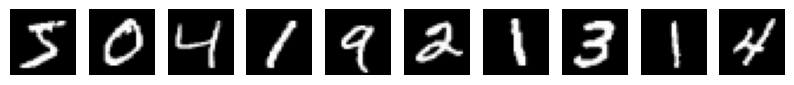

In [4]:
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

#### 1.4. Распределение классов:

In [5]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Распределение классов в тренировочном наборе:")
print(dict(zip(unique_train, counts_train)))

print("\nРаспределение классов в тестовом наборе:")
print(dict(zip(unique_test, counts_test)))

Распределение классов в тренировочном наборе:
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}

Распределение классов в тестовом наборе:
{np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


#### 1.5. Аугментация данных:

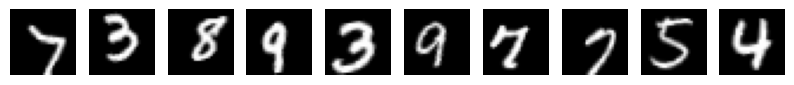

In [7]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

augmented_images, augmented_labels = next(
    datagen.flow(x_train, y_train, batch_size=10)
)

plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(augmented_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

#### 1.6 Преобразование изображений в одномерный массив для PCA:

In [8]:
# Преобразование изображений 28x28x1 в одномерные векторы длиной 784
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print(f"Размер тренировочных данных после преобразования: {x_train_flat.shape}")
print(f"Размер тестовых данных после преобразования: {x_test_flat.shape}")

Размер тренировочных данных после преобразования: (60000, 784)
Размер тестовых данных после преобразования: (10000, 784)


#### 1.7 Cтатистический анализ пикселей:

In [9]:
print(f"Минимум: {x_train.min()}")
print(f"Максимум: {x_train.max()}")
print(f"Среднее: {x_train.mean():.4f}")
print(f"Стандартное отклонение: {x_train.std():.4f}")

Минимум: 0.0
Максимум: 1.0
Среднее: 0.1307
Стандартное отклонение: 0.3081


#### 1.8 Добавление гауссовского шума:

In [10]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Ограничиваем значения пикселей диапазоном [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print(f"Форма шумных тренировочных данных: {x_train_noisy.shape}")
print(f"Форма шумных тестовых данных: {x_test_noisy.shape}")

Форма шумных тренировочных данных: (60000, 28, 28, 1)
Форма шумных тестовых данных: (10000, 28, 28, 1)


#### 1.9 Bизуализация зашумленных изображений:

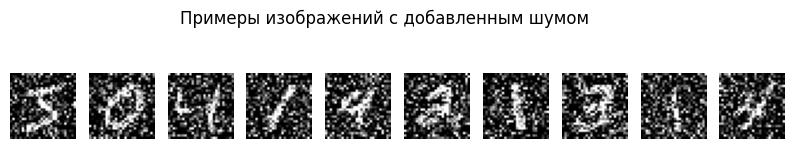

In [11]:
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Примеры изображений с добавленным шумом")
plt.show()

#### 1.10 Создание поднабора данных:

In [13]:
small_x_train = x_train[:1000]
small_y_train = y_train[:1000]

print(f"Размер небольшого поднабора изображений: {small_x_train.shape}")
print(f"Размер небольшого поднабора меток: {small_y_train.shape}")

Размер небольшого поднабора изображений: (1000, 28, 28, 1)
Размер небольшого поднабора меток: (1000,)


----

#### 1.11 Ответы на вопросы анализа к шагу 1:

- **Как распределение классов влияет на обучение модели?**
Если одних цифр в данных намного больше, чем других, модель может лучше восстанавливать и генерировать именно эти классы. В MNIST распределение классов достаточно сбалансировано, поэтому модель получает примеры всех цифр примерно равномерно.

- **Какие преобразования данных могут улучшить генерацию изображений?**
Для MNIST полезны небольшие повороты, сдвиги, масштабирование и умеренный zoom. Слишком сильные преобразования могут искажать цифры и ухудшать обучение.

- **Как добавление шума может помочь в обучении устойчивых моделей?**
Шум заставляет модель выделять устойчивые признаки изображения, например форму цифры, а не запоминать отдельные пиксели. Это помогает автоэнкодеру лучше обобщать данные.

---

### 2. Реализация классического автокодировщика AE


#### 2.1 Создание архитектуры AE:

In [14]:
# Размер латентного пространства классического AE
ae_latent_dim = 64

# Входное изображение
input_img = Input(shape=(28, 28, 1))

# Энкодер: изображение -> вектор признаков
x = Flatten()(input_img)
encoded = Dense(ae_latent_dim, activation="relu", name="ae_latent_vector")(x)

# Декодер: вектор признаков -> восстановленное изображение
x = Dense(28 * 28, activation="sigmoid")(encoded)
decoded = Reshape((28, 28, 1))(x)

# Полная модель автокодировщика
autoencoder = Model(input_img, decoded, name="Classic_Autoencoder")

# Отдельная модель энкодера пригодится позже для анализа латентного пространства
encoder_ae = Model(input_img, encoded, name="AE_Encoder")

autoencoder.compile(
    optimizer=Adam(),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "Classic_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_latent_vector (Dense)        │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.2 Реконструкция до обучения:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


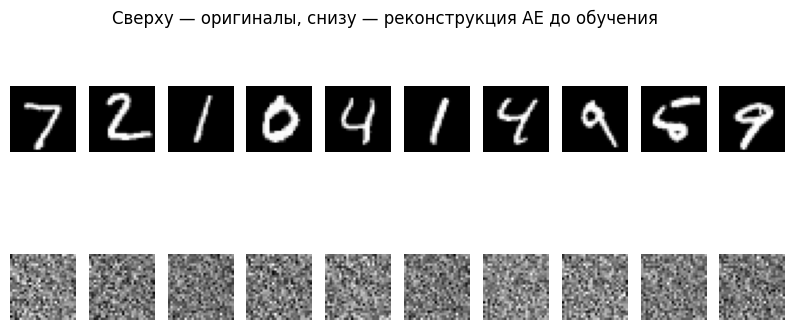

In [15]:
# Реконструкция до обучения, когда веса модели еще случайные
decoded_imgs_before = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Реконструкция до обучения
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(decoded_imgs_before[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Сверху - оригиналы, снизу - реконструкция AE до обучения")
plt.show()

#### 2.3 Обучение AE:

In [16]:
history_ae = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2519 - val_loss: 0.1667
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1486 - val_loss: 0.1323
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1228 - val_loss: 0.1137
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1079 - val_loss: 0.1025
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0983 - val_loss: 0.0948
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0916 - val_loss: 0.0894
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0868 - val_loss: 0.0855
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0833 - val_loss: 0.0824
Epoch 9/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0807 - val_loss: 0.0802
Epoch 10/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0789 - val_loss: 0.0787


#### 2.4 График функции потерь AE:

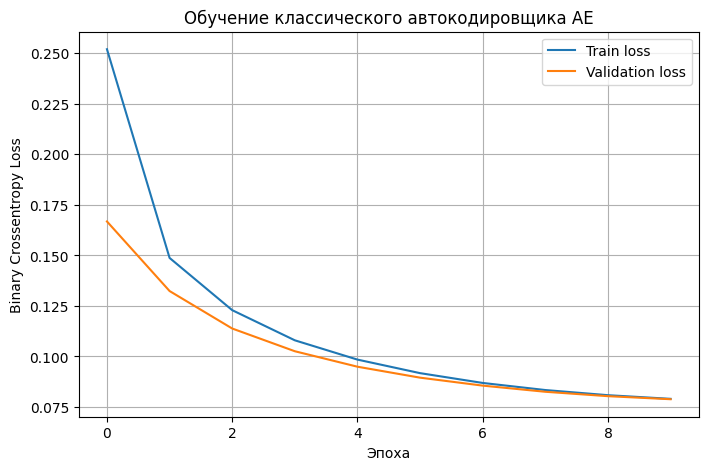

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history_ae.history["loss"], label="Train loss")
plt.plot(history_ae.history["val_loss"], label="Validation loss")

plt.title("Обучение классического автокодировщика AE")
plt.xlabel("Эпоха")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid()
plt.show()

#### 2.5 Реконструкция после обучения:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


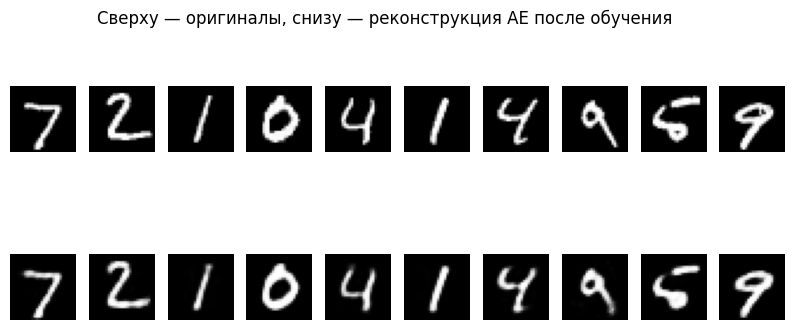

In [18]:
decoded_imgs_after = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Реконструкция после обучения
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(decoded_imgs_after[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Сверху — оригиналы, снизу — реконструкция AE после обучения")
plt.show()

#### 2.6 Сравнение до и после обучения в одной визуализации:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


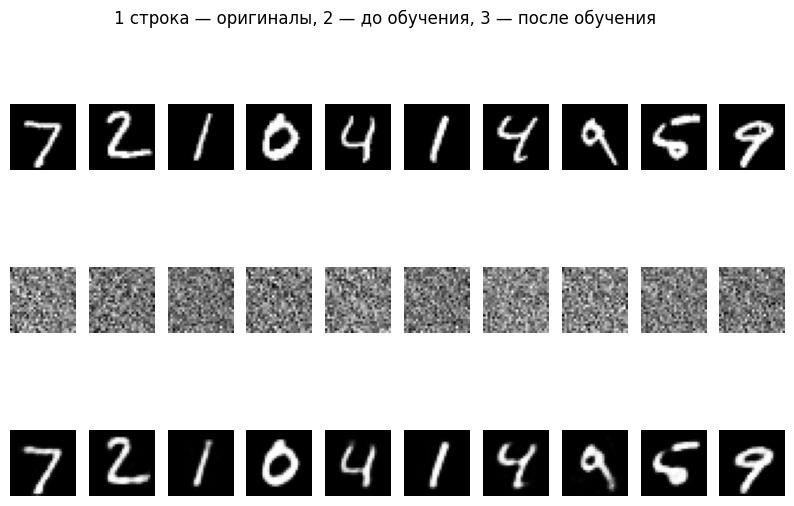

In [19]:
decoded_imgs_after = autoencoder.predict(x_test[:10])

plt.figure(figsize=(10, 6))

for i in range(10):
    # Оригинал
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # До обучения
    plt.subplot(3, 10, 10 + i + 1)
    plt.imshow(decoded_imgs_before[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # После обучения
    plt.subplot(3, 10, 20 + i + 1)
    plt.imshow(decoded_imgs_after[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("1 строка — оригиналы, 2 — до обучения, 3 — после обучения")
plt.show()

#### 2.7 Расчет MSE для AE:

In [20]:
# Восстанавливаем весь тестовый набор
x_test_ae_reconstructed = autoencoder.predict(x_test)

# Переводим изображения в плоский вид для расчета MSE
x_test_ae_reconstructed_flat = x_test_ae_reconstructed.reshape(len(x_test_ae_reconstructed), -1)

mse_ae = mean_squared_error(x_test_flat, x_test_ae_reconstructed_flat)

print(f"MSE для AE: {mse_ae:.6f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
MSE для AE: 0.005109


#### 2.8 Вывод по второму шагу:

- Классический автокодировщик научился сжимать изображения MNIST в латентный вектор размерности 64 и восстанавливать их обратно. После обучения реконструкции должны стать значительно похожими на исходные цифры, хотя мелкие детали могут быть потеряны из-за сжатия.

### 3. Реализация вариационного автокодировщика VAE:

#### 3.1 — Подготовка Sampling-слоя:

In [22]:
# Фиксируем размерность латентного пространства.
# В методичке для визуализации используется latent_dim = 2.
latent_dim = 2


class Sampling(Layer):
    """
    Слой сэмплирования для VAE.

    Энкодер выдает два вектора:
    mu      — среднее латентного распределения
    log_var — логарифм дисперсии латентного распределения

    Затем мы получаем z по формуле:
    z = mu + exp(0.5 * log_var) * epsilon,
    где epsilon берется из стандартного нормального распределения.
    """

    def call(self, inputs):
        mu, log_var = inputs

        batch_size = tf.shape(mu)[0]
        latent_dim = tf.shape(mu)[1]

        epsilon = tf.random.normal(shape=(batch_size, latent_dim))

        return mu + tf.exp(0.5 * log_var) * epsilon

#### 3.2 — Слой функции потерь VAE:

In [23]:
class VAELossLayer(Layer):
    """
    Слой, который добавляет функцию потерь VAE к модели.

    Loss VAE состоит из двух частей:
    1. reconstruction_loss — ошибка восстановления изображения.
    2. kl_loss — KL-дивергенция, которая приближает латентное распределение к N(0, 1).
    """

    def call(self, inputs):
        input_img, output_img, mu, log_var = inputs

        # Ошибка реконструкции.
        # binary_crossentropy вернет ошибку по пикселям.
        reconstruction_loss = tf.keras.losses.binary_crossentropy(input_img, output_img)

        # Суммируем ошибку по ширине и высоте изображения.
        reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=(1, 2))

        # KL-дивергенция между Q(z|x) и стандартным нормальным распределением N(0, 1)
        kl_loss = -0.5 * tf.reduce_sum(
            1 + log_var - tf.square(mu) - tf.exp(log_var),
            axis=1
        )

        # Общая ошибка VAE
        total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        # Добавляем loss внутрь модели
        self.add_loss(total_loss)

        return output_img

#### 3.3 — Построение энкодера VAE:

In [24]:
# Входное изображение
vae_input = Input(shape=(28, 28, 1), name="vae_input")

# Преобразуем изображение в вектор
x = Flatten(name="vae_flatten")(vae_input)

# Скрытый слой энкодера
x = Dense(128, activation="relu", name="vae_encoder_dense")(x)

# Среднее латентного распределения
mu = Dense(latent_dim, name="mu")(x)

# Логарифм дисперсии латентного распределения
log_var = Dense(latent_dim, name="log_var")(x)

# Сэмплирование латентной точки z
z = Sampling(name="z")([mu, log_var])

# Отдельная модель энкодера
encoder = Model(vae_input, [mu, log_var, z], name="VAE_Encoder")

encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_flatten         │ (None, 784)       │          0 │ vae_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_dense   │ (None, 128)       │    100,480 │ vae_flatten[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        258 │ vae_encoder_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        258 │ vae_encoder_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

 Non-trainable params: 0 (0.00 B)

#### 3.4 — Построение декодера VAE:

In [25]:
# Вход декодера — точка в латентном пространстве
decoder_input = Input(shape=(latent_dim,), name="decoder_input")

# Скрытый слой декодера
x = Dense(128, activation="relu", name="vae_decoder_dense")(decoder_input)

# Восстановление 784 пикселей
x = Dense(28 * 28, activation="sigmoid", name="vae_decoder_output_dense")(x)

# Возвращаем форму изображения 28x28x1
decoder_output = Reshape((28, 28, 1), name="vae_decoder_output")(x)

# Отдельная модель декодера
decoder = Model(decoder_input, decoder_output, name="VAE_Decoder")

decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_decoder_dense (Dense)       │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_decoder_output_dense        │ (None, 784)            │       101,136 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vae_decoder_output (Reshape)    │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

#### 3.5 — Сборка полной модели VAE:

In [26]:
# Получаем восстановленное изображение из декодера
vae_output_raw = decoder(z)

# Добавляем слой с функцией потерь VAE
vae_output = VAELossLayer(name="vae_loss_layer")(
    [vae_input, vae_output_raw, mu, log_var]
)

# Полная модель VAE
vae = Model(vae_input, vae_output, name="Variational_Autoencoder")

# Так как loss добавлен внутри VAELossLayer, отдельно loss указывать не нужно
vae.compile(optimizer=Adam())

vae.summary()

Model: "Variational_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_flatten         │ (None, 784)       │          0 │ vae_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_dense   │ (None, 128)       │    100,480 │ vae_flatten[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        258 │ vae_encoder_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        258 │ vae_encoder_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VAE_Decoder         │ (None, 28, 28, 1) │    101,520 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss_layer      │ (None, 28, 28, 1) │          0 │ vae_input[0][0],  │
│ (VAELossLayer)      │                   │            │ VAE_Decoder[0][0… │
│                     │                   │            │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 202,516 (791.08 KB)

 Trainable params: 202,516 (791.08 KB)

 Non-trainable params: 0 (0.00 B)

#### 3.6 — Реконструкция VAE до обучения:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


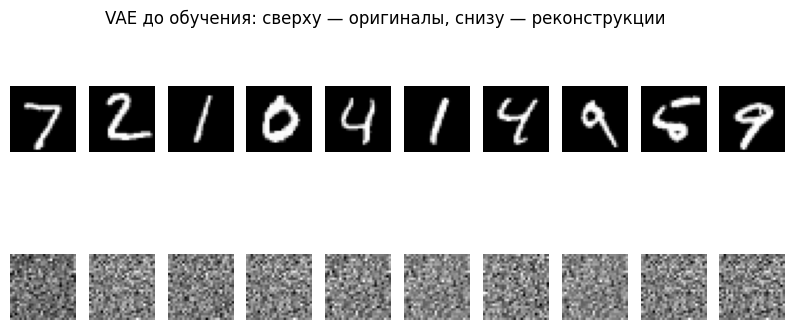

In [27]:
vae_reconstructed_before = vae.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Реконструкция до обучения
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(vae_reconstructed_before[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("VAE до обучения: сверху — оригиналы, снизу — реконструкции")
plt.show()

#### 3.7 Обучение VAE:

In [28]:
history_vae = vae.fit(
    x_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 243.9101 - val_loss: 191.7898
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 185.4639 - val_loss: 179.4388
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 177.0201 - val_loss: 172.6485
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 172.2465 - val_loss: 169.7840
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 170.1472 - val_loss: 168.1998
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 168.7519 - val_loss: 167.0533
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 167.6546 - val_loss: 166.1254
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 166.6782 - val_loss: 165.3669
Epoch 9/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 165.8628 - val_loss: 164.5505
Epoch 10/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 165.1053 - val_loss: 163.9207


#### 3.8 — График функции потерь VAE:

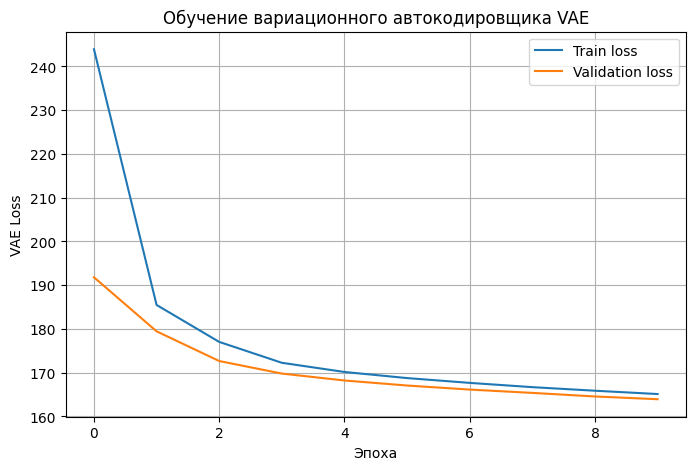

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history_vae.history["loss"], label="Train loss")
plt.plot(history_vae.history["val_loss"], label="Validation loss")

plt.title("Обучение вариационного автокодировщика VAE")
plt.xlabel("Эпоха")
plt.ylabel("VAE Loss")
plt.legend()
plt.grid()
plt.show()

#### 3.9 — Реконструкция VAE после обучения:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


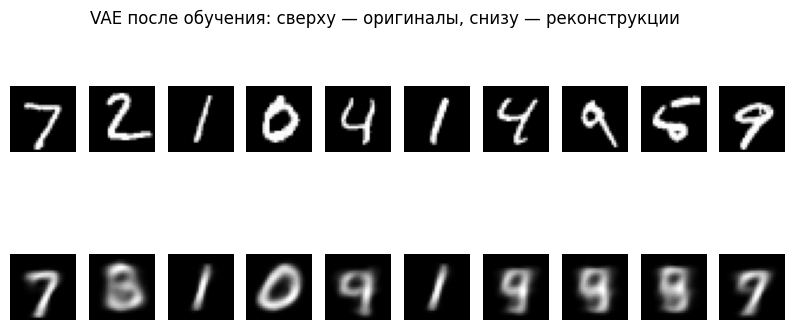

In [30]:
vae_reconstructed_after = vae.predict(x_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинал
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Реконструкция после обучения
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(vae_reconstructed_after[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("VAE после обучения: сверху — оригиналы, снизу — реконструкции")
plt.show()

- Реконструкции могут быть более размытыми, чем у AE, потому что VAE дополнительно регуляризует латентное пространство.

#### 3.10 — Сравнение VAE до и после обучения:

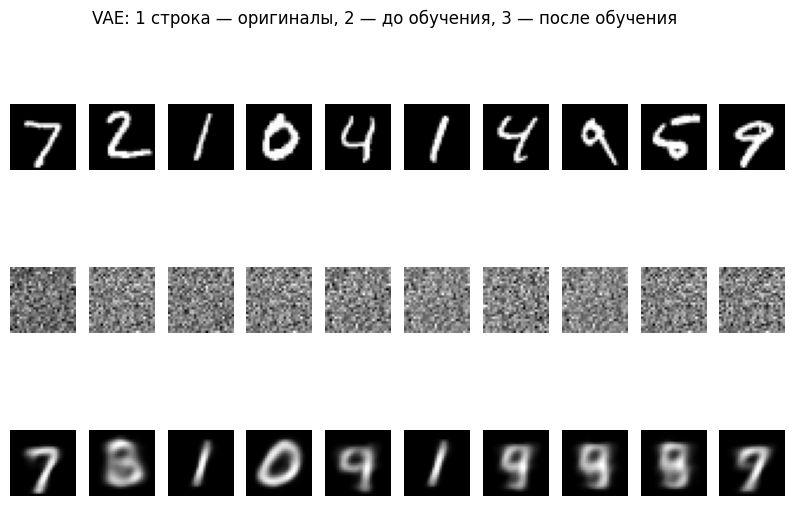

In [31]:
plt.figure(figsize=(10, 6))

for i in range(10):
    # Оригинал
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # До обучения
    plt.subplot(3, 10, 10 + i + 1)
    plt.imshow(vae_reconstructed_before[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # После обучения
    plt.subplot(3, 10, 20 + i + 1)
    plt.imshow(vae_reconstructed_after[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("VAE: 1 строка — оригиналы, 2 — до обучения, 3 — после обучения")
plt.show()

#### 3.11 — Визуализация латентного пространства VAE:

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


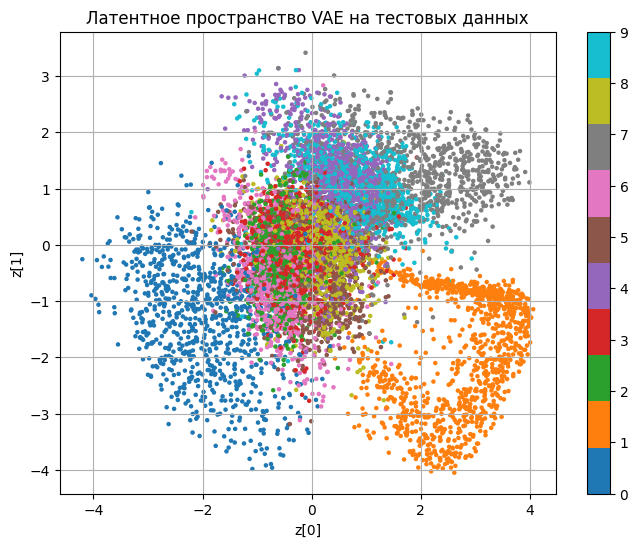

In [32]:
# Получаем mu, log_var и z для тестовых изображений
z_mean_test, z_log_var_test, z_test = encoder.predict(x_test, batch_size=256)

plt.figure(figsize=(8, 6))

plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Латентное пространство VAE на тестовых данных")
plt.grid()
plt.show()

- Каждая точка соответствует одному изображению MNIST. Цвет показывает настоящую цифру от 0 до 9.

#### 3.12 — Расчет MSE для VAE:

In [33]:
# Восстанавливаем весь тестовый набор
x_test_vae_reconstructed = vae.predict(x_test, batch_size=256)

# Преобразуем реконструкции в одномерные векторы для MSE
x_test_vae_reconstructed_flat = x_test_vae_reconstructed.reshape(
    len(x_test_vae_reconstructed),
    -1
)

mse_vae = mean_squared_error(x_test_flat, x_test_vae_reconstructed_flat)

print(f"MSE для VAE: {mse_vae:.6f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
MSE для VAE: 0.048500


#### 3.13 Вывод по третьему шагу
- В этом шаге была реализована модель VAE. В отличие от обычного автокодировщика, VAE кодирует изображение не в одну фиксированную точку, а в распределение, заданное параметрами mu и log_var. Затем из этого распределения выбирается латентный вектор z, который декодер использует для восстановления изображения;

- Главное преимущество VAE — возможность генерировать новые изображения из случайных точек латентного пространства;

### 4. Сравнение PCA, AE и VAE:

#### 4.1 Обучение PCA и восстановление изображений:

In [34]:
# Количество главных компонент, как в методичке
pca_components = 64

# Создаем PCA
pca = PCA(n_components=pca_components)

# Обучаем PCA на тренировочных данных
x_train_pca = pca.fit_transform(x_train_flat)

# Применяем PCA к тестовым данным
x_test_pca = pca.transform(x_test_flat)

# Восстанавливаем данные обратно из PCA-пространства
x_test_pca_reconstructed_flat = pca.inverse_transform(x_test_pca)

# Возвращаем форму изображений 28x28x1
x_test_pca_reconstructed = x_test_pca_reconstructed_flat.reshape(-1, 28, 28, 1)

print("Размерность после PCA:", x_test_pca.shape)
print("Размер восстановленных изображений:", x_test_pca_reconstructed.shape)

Размерность после PCA: (10000, 64)
Размер восстановленных изображений: (10000, 28, 28, 1)


#### 4.3 Визуализация реконструкции PCA:

- Сравним исходные изображения и изображения, восстановленные после сжатия PCA:

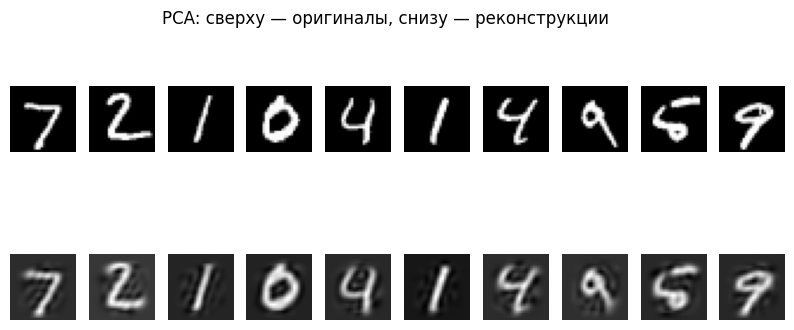

In [35]:
def visualize_reconstruction(original, reconstructed, title, num_images=10):
    plt.figure(figsize=(10, 4))

    for i in range(num_images):
        # Оригинал
        plt.subplot(2, num_images, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap="gray")
        plt.axis("off")

        # Восстановление
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()


visualize_reconstruction(
    x_test,
    x_test_pca_reconstructed,
    "PCA: сверху — оригиналы, снизу — реконструкции"
)

#### 4.4 Получение реконструкций AE и VAE:

In [36]:
# Реконструкция тестовых изображений с помощью обычного автокодировщика AE
x_test_ae_reconstructed = autoencoder.predict(x_test, batch_size=256)

# Реконструкция тестовых изображений с помощью VAE
x_test_vae_reconstructed = vae.predict(x_test, batch_size=256)

print("AE reconstructed:", x_test_ae_reconstructed.shape)
print("VAE reconstructed:", x_test_vae_reconstructed.shape)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
AE reconstructed: (10000, 28, 28, 1)
VAE reconstructed: (10000, 28, 28, 1)


#### 4.5 Общее сравнение реконструкций PCA, AE и VAE:

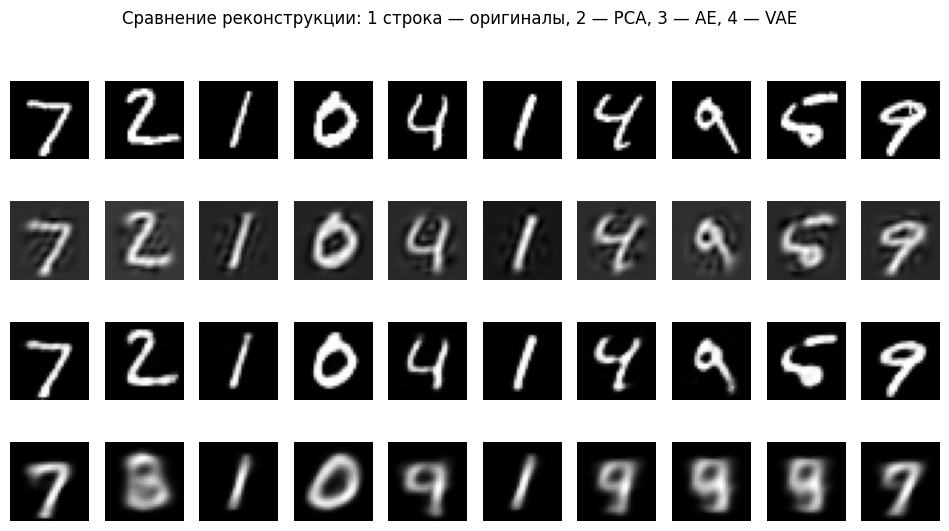

In [37]:
num_images = 10

plt.figure(figsize=(12, 6))

for i in range(num_images):
    # Оригиналы
    plt.subplot(4, num_images, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # PCA
    plt.subplot(4, num_images, num_images + i + 1)
    plt.imshow(x_test_pca_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # AE
    plt.subplot(4, num_images, 2 * num_images + i + 1)
    plt.imshow(x_test_ae_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # VAE
    plt.subplot(4, num_images, 3 * num_images + i + 1)
    plt.imshow(x_test_vae_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(
    "Сравнение реконструкции: 1 строка — оригиналы, 2 — PCA, 3 — AE, 4 — VAE"
)
plt.show()

- PCA дает более размытые изображения, потому что использует только линейные преобразования;
- AE лучше восстанавливает форму цифр, потому что использует нелинейные слои;
- VAE может давать более сглаженные реконструкции, потому что его латентное пространство регуляризуется через KL-дивергенцию.

#### 4.6 Расчет MSE для PCA, AE и VAE:

In [38]:
# Преобразуем реконструкции AE и VAE в одномерные векторы
x_test_ae_reconstructed_flat = x_test_ae_reconstructed.reshape(len(x_test_ae_reconstructed), -1)
x_test_vae_reconstructed_flat = x_test_vae_reconstructed.reshape(len(x_test_vae_reconstructed), -1)

# Считаем MSE
mse_pca = mean_squared_error(x_test_flat, x_test_pca_reconstructed_flat)
mse_ae = mean_squared_error(x_test_flat, x_test_ae_reconstructed_flat)
mse_vae = mean_squared_error(x_test_flat, x_test_vae_reconstructed_flat)

print(f"MSE для PCA: {mse_pca:.6f}")
print(f"MSE для AE:  {mse_ae:.6f}")
print(f"MSE для VAE: {mse_vae:.6f}")

MSE для PCA: 0.009047
MSE для AE:  0.005109
MSE для VAE: 0.048492


#### 4.7 Визуальное сравнение MSE:

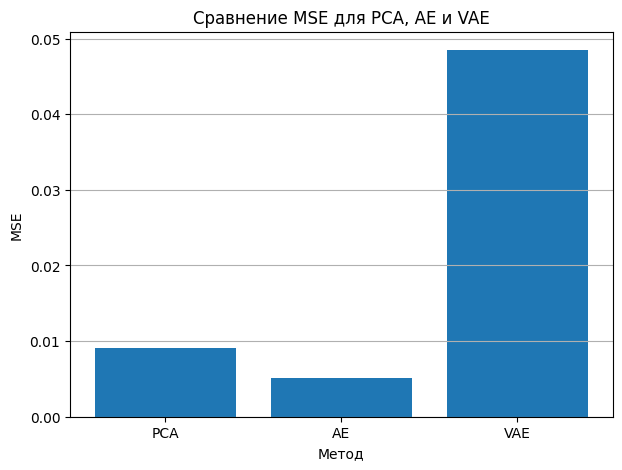

In [39]:
methods = ["PCA", "AE", "VAE"]
mse_values = [mse_pca, mse_ae, mse_vae]

plt.figure(figsize=(7, 5))
plt.bar(methods, mse_values)
plt.title("Сравнение MSE для PCA, AE и VAE")
plt.xlabel("Метод")
plt.ylabel("MSE")
plt.grid(axis="y")
plt.show()

#### 4.8 Визуализиция PCA в 2D:

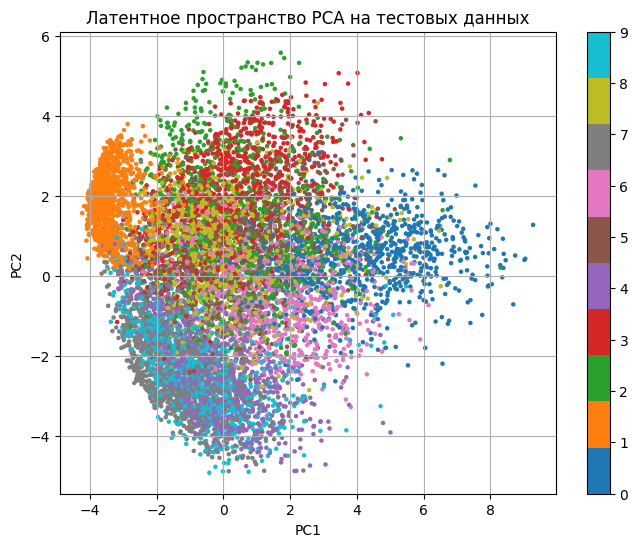

In [40]:
# Уменьшаем размерность тестовых данных до 2D с помощью PCA
pca_2d = PCA(n_components=2)
x_test_pca_2d = pca_2d.fit_transform(x_test_flat)

plt.figure(figsize=(8, 6))
plt.scatter(
    x_test_pca_2d[:, 0],
    x_test_pca_2d[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Латентное пространство PCA на тестовых данных")
plt.grid()
plt.show()

- PCA строит двумерное линейное представление данных. Цвет точки соответствует классу цифры.

#### 4.9 Латентное пространство AE:

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Размер латентного пространства AE: (10000, 64)


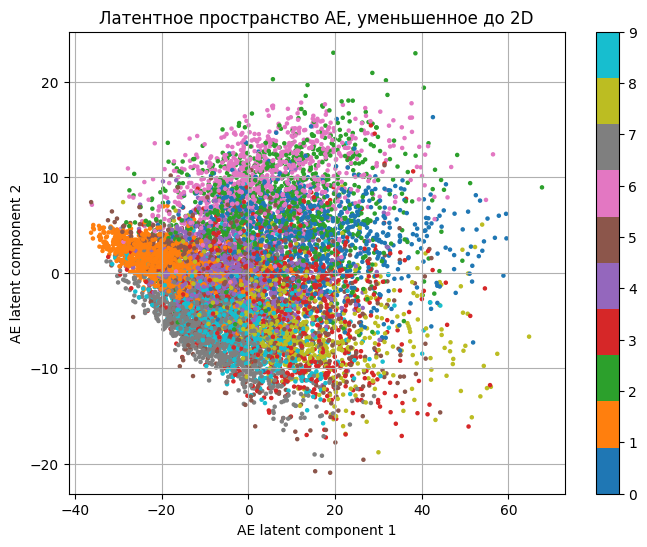

In [41]:
# Создаем отдельный энкодер для AE.
# В базовой архитектуре AE:
# autoencoder.layers[0] — Input
# autoencoder.layers[1] — Flatten
# autoencoder.layers[2] — Dense(64), то есть латентное представление

ae_encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.layers[2].output
)

# Получаем латентные признаки AE
x_test_ae_latent = ae_encoder.predict(x_test, batch_size=256)

print("Размер латентного пространства AE:", x_test_ae_latent.shape)

# Так как у AE латентное пространство имеет размер 64,
# уменьшим его до 2D с помощью PCA для визуализации
ae_latent_2d = PCA(n_components=2).fit_transform(x_test_ae_latent)

plt.figure(figsize=(8, 6))
plt.scatter(
    ae_latent_2d[:, 0],
    ae_latent_2d[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar()
plt.xlabel("AE latent component 1")
plt.ylabel("AE latent component 2")
plt.title("Латентное пространство AE, уменьшенное до 2D")
plt.grid()
plt.show()

- У обычного AE латентное пространство имеет размерность 64, поэтому для отображения на графике мы дополнительно уменьшаем его до 2D.

#### 4.10 Латентное пространство VAE:

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


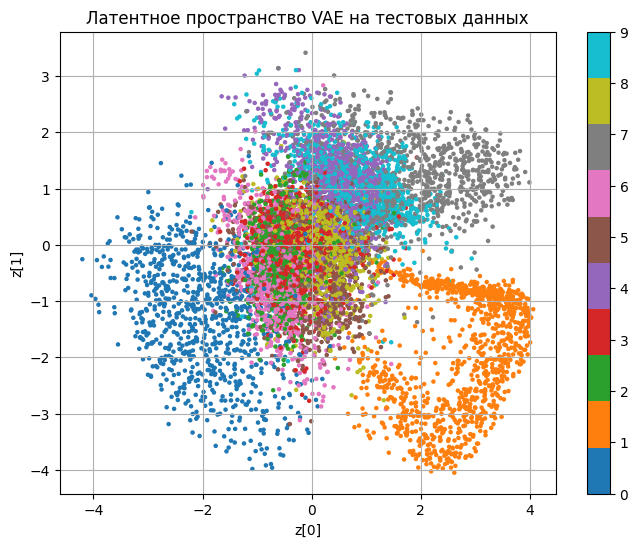

In [42]:
# Получаем средние значения mu для тестовых изображений
z_mean_test, z_log_var_test, z_test = encoder.predict(x_test, batch_size=256)

plt.figure(figsize=(8, 6))
plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Латентное пространство VAE на тестовых данных")
plt.grid()
plt.show()

- Для VAE мы визуализируем mu, то есть среднее значение латентного распределения. Так как в предыдущем шаге использовалось latent_dim = 2, VAE уже имеет двумерное латентное пространство.

#### 4.11 График сохраненной дисперсии:

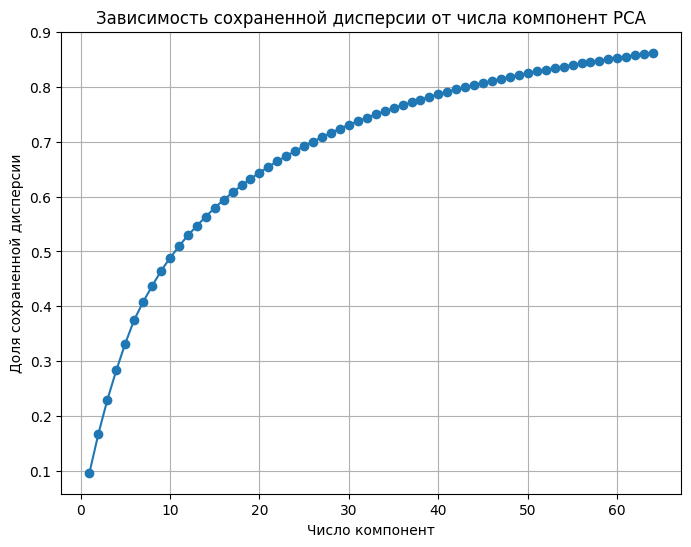

Доля сохраненной дисперсии при 64 компонентах: 0.8619


In [43]:
explained_variance = []
components_range = range(1, 65)

for n in components_range:
    pca_temp = PCA(n_components=n)
    pca_temp.fit(x_train_flat)
    explained_variance.append(np.sum(pca_temp.explained_variance_ratio_))

plt.figure(figsize=(8, 6))
plt.plot(components_range, explained_variance, marker="o")
plt.title("Зависимость сохраненной дисперсии от числа компонент PCA")
plt.xlabel("Число компонент")
plt.ylabel("Доля сохраненной дисперсии")
plt.grid()
plt.show()

print(f"Доля сохраненной дисперсии при 64 компонентах: {explained_variance[-1]:.4f}")

#### 4.12 Таблица дисперсии для нескольких размерностей:

In [44]:
for n in [2, 8, 16, 32, 64]:
    pca_temp = PCA(n_components=n)
    pca_temp.fit(x_train_flat)
    variance = np.sum(pca_temp.explained_variance_ratio_)
    print(f"Компонент: {n:2d}, сохраненная дисперсия: {variance:.4f}")

Компонент:  2, сохраненная дисперсия: 0.1680
Компонент:  8, сохраненная дисперсия: 0.4369
Компонент: 16, сохраненная дисперсия: 0.5942
Компонент: 32, сохраненная дисперсия: 0.7436
Компонент: 64, сохраненная дисперсия: 0.8619


#### 4.13 Подготовка данных PCA для AE:

In [45]:
# Используем PCA с 64 компонентами
pca_for_ae = PCA(n_components=64)

x_train_pca_for_ae = pca_for_ae.fit_transform(x_train_flat)
x_test_pca_for_ae = pca_for_ae.transform(x_test_flat)

print("x_train_pca_for_ae:", x_train_pca_for_ae.shape)
print("x_test_pca_for_ae:", x_test_pca_for_ae.shape)

x_train_pca_for_ae: (60000, 64)
x_test_pca_for_ae: (10000, 64)


#### 4.14 AE для PCA-признаков:

In [46]:
# Вход — 64 PCA-компоненты
pca_ae_input = Input(shape=(64,), name="pca_ae_input")

# Сжатие PCA-признаков
x = Dense(32, activation="relu", name="pca_ae_encoded")(pca_ae_input)

# Восстановление PCA-признаков
pca_ae_output = Dense(64, activation="linear", name="pca_ae_output")(x)

# Модель AE для PCA-пространства
pca_autoencoder = Model(pca_ae_input, pca_ae_output, name="PCA_Autoencoder")

pca_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

pca_autoencoder.summary()

Model: "PCA_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pca_ae_input (InputLayer)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pca_ae_encoded (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pca_ae_output (Dense)           │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,192 (16.38 KB)

 Trainable params: 4,192 (16.38 KB)

 Non-trainable params: 0 (0.00 B)

#### 4.15 Обучение PCA + AE:

In [47]:
history_pca_ae = pca_autoencoder.fit(
    x_train_pca_for_ae,
    x_train_pca_for_ae,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5351 - val_loss: 0.3239
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2586 - val_loss: 0.2147
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1940 - val_loss: 0.1746
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1621 - val_loss: 0.1485
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1386 - val_loss: 0.1277
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1207 - val_loss: 0.1138
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1106 - val_loss: 0.1072
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1059 - val_loss: 0.1041
Epoch 9/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1034 - val_loss: 0.1023
Epoch 10/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1019 - val_loss: 0.1011


#### 4.16 Восстановление изображений через PCA + AE:

In [48]:
# Восстанавливаем PCA-признаки через AE
x_test_pca_ae_reconstructed = pca_autoencoder.predict(x_test_pca_for_ae, batch_size=256)

# Возвращаемся из PCA-пространства обратно к пикселям
x_test_pca_ae_reconstructed_flat = pca_for_ae.inverse_transform(x_test_pca_ae_reconstructed)

# Возвращаем форму изображений
x_test_pca_ae_reconstructed_images = x_test_pca_ae_reconstructed_flat.reshape(-1, 28, 28, 1)

# Считаем MSE
mse_pca_ae = mean_squared_error(x_test_flat, x_test_pca_ae_reconstructed_flat)

print(f"MSE для PCA:      {mse_pca:.6f}")
print(f"MSE для AE:       {mse_ae:.6f}")
print(f"MSE для VAE:      {mse_vae:.6f}")
print(f"MSE для PCA + AE: {mse_pca_ae:.6f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MSE для PCA:      0.009047
MSE для AE:       0.005109
MSE для VAE:      0.048492
MSE для PCA + AE: 0.017123


#### 4.17 Визуализация PCA + AE:

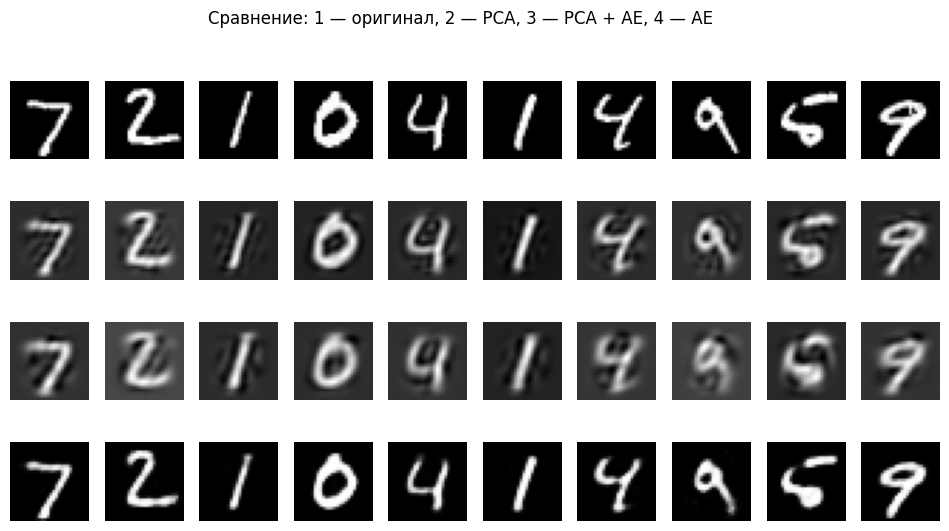

In [49]:
num_images = 10

plt.figure(figsize=(12, 6))

for i in range(num_images):
    # Оригинал
    plt.subplot(4, num_images, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # PCA
    plt.subplot(4, num_images, num_images + i + 1)
    plt.imshow(x_test_pca_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # PCA + AE
    plt.subplot(4, num_images, 2 * num_images + i + 1)
    plt.imshow(x_test_pca_ae_reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # AE
    plt.subplot(4, num_images, 3 * num_images + i + 1)
    plt.imshow(x_test_ae_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Сравнение: 1 — оригинал, 2 — PCA, 3 — PCA + AE, 4 — AE")
plt.show()

- PCA уже потерял часть информации, а AE дополнительно сжимает PCA-признаки.

#### 4.18 Вывод по четвертому шагу

- PCA выполняет линейное сжатие данных и хорошо сохраняет общую структуру изображений, но часто дает размытые реконструкции. AE использует нелинейные преобразования, поэтому обычно лучше восстанавливает форму цифр. VAE дополнительно регуляризует латентное пространство, из-за чего реконструкции могут быть менее четкими, но такое пространство лучше подходит для генерации новых изображений;

- По метрике MSE можно количественно сравнить качество восстановления: чем меньше значение, тем точнее модель восстановила изображения. При этом визуальное качество и MSE не всегда полностью совпадают, особенно для VAE, так как его задача не только восстановление, но и формирование регулярного латентного пространства.

### 5. Генерация данных с помощью VAE

---

#### 5.1 — Генерация случайных изображений из латентного пространства:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


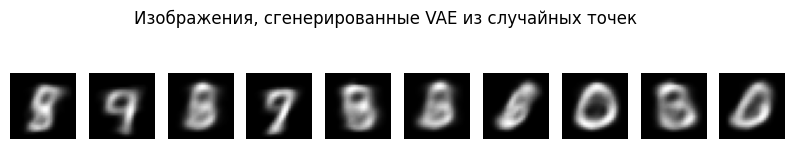

In [50]:
# Для воспроизводимости результата
np.random.seed(42)

# Генерируем 10 случайных точек из нормального распределения N(0, 1)
latent_samples = np.random.normal(size=(10, latent_dim))

# Декодер превращает латентные точки в изображения
generated_images = decoder.predict(latent_samples)

# Визуализация сгенерированных изображений
plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Изображения, сгенерированные VAE из случайных точек")
plt.show()

- VAE обучается так, чтобы латентное пространство было похоже на нормальное распределение N(0, 1). Поэтому мы можем взять случайные точки из этого распределения и передать их в decoder;

#### 5.2 — Сравнение оригинальных и сгенерированных изображений:

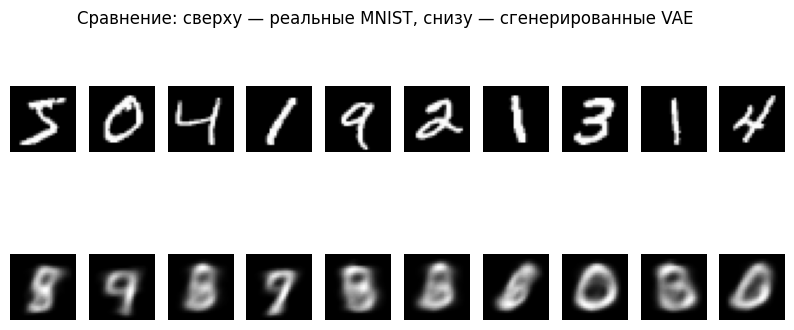

In [51]:
plt.figure(figsize=(10, 4))

for i in range(10):
    # Оригинальные изображения MNIST
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Сгенерированные изображения VAE
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Сравнение: сверху — реальные MNIST, снизу — сгенерированные VAE")
plt.show()

- Нижняя строка показывает изображения, которых не было в датасете, но которые VAE попытался сгенерировать из случайных латентных точек.

- Сгенерированные изображения напоминают рукописные цифры, однако часть из них  размыты или не полностью не похожи на конкретный класс. Это связано с тем, что VAE не просто запоминает изображения, а обучается формировать непрерывное вероятностное латентное пространство. При малой размерности латентного пространства, например latent_dim = 2, модели сложнее сохранить все детали цифр.